# 1.prepare

In [2]:
import numpy as np
import pandas as pd

import scanpy as sc
import scvelo as scv

import matplotlib.pyplot as plt
import seaborn as sns

import myutils

import random
import os

myutils.set_figure_params()
sc.settings.verbosity = 3

In [4]:
adata = sc.read_h5ad("1.3.final_all_for_open_access.h5ad")
adata

AnnData object with n_obs × n_vars = 166418 × 25998
    obs: 'cell_id', 'sample', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'condition', 'leiden', 'CellType', 'condition_final'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'CellType_colors', 'batch_colors', 'condition_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

# 1.figure-A-B

In [5]:
all_colors = ["#96C3D8","#5D9BBE","#F5B375","#C0937E","#67A59B","#A4D38E","#4A9D47","#F19294","#E45A5F","#3477A9","#BDA7CB","#684797","#9983B7","#CD9A99","#DD4B52","#DA8F6F","#F58135"]
#all_colors = ["#96C3D8","#5D9BBE","#F5B375","#67A59B","#A4D38E","#4A9D47","#F19294","#E45A5F","#3477A9","#BDA7CB","#684797","#9983B7","#CD9A99","#DD4B52","#DA8F6F","#F58135"]
all_colors = np.array(all_colors)
use_colors = np.linspace(0,len(all_colors)-1,len(adata.obs['CellType'].unique()))
use_colors = np.array(use_colors,dtype="int")
use_colors = all_colors[use_colors]
use_colors

array(['#96C3D8', '#5D9BBE', '#C0937E', '#A4D38E', '#F19294', '#E45A5F',
       '#BDA7CB', '#9983B7', '#DD4B52', '#F58135'], dtype='<U7')

In [6]:
adata.uns['CellType_colors'] = np.array(['#96C3D8',  '#E45A5F', '#A4D38E', '#C0937E', '#F19294','#5D9BBE','#BDA7CB', '#9983B7', '#CD9A99', '#F58135'])
#adata.uns['CellType_colors'] = use_colors

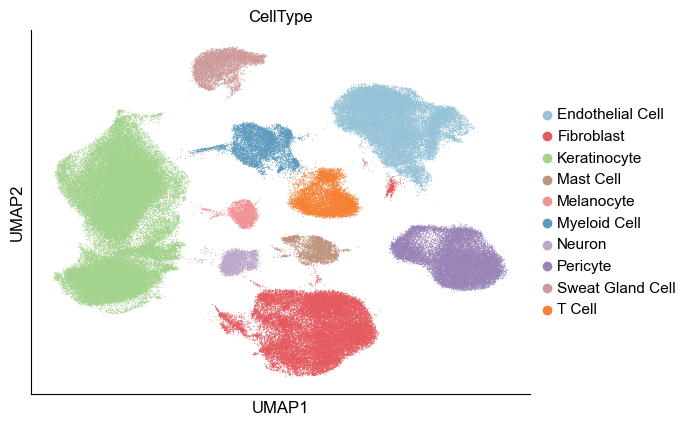

In [9]:
fig,ax = plt.subplots()
sc.pl.embedding(adata,"umap",color=["CellType"],ax=ax,show=False,size=2.)
fig.savefig("Figure1B.pdf",format="pdf",bbox_inches="tight")
plt.show()

In [10]:
print((adata.obs['condition']=="NS").sum(),(adata.obs['condition']=="Scar/keloid").sum())

51909 114509


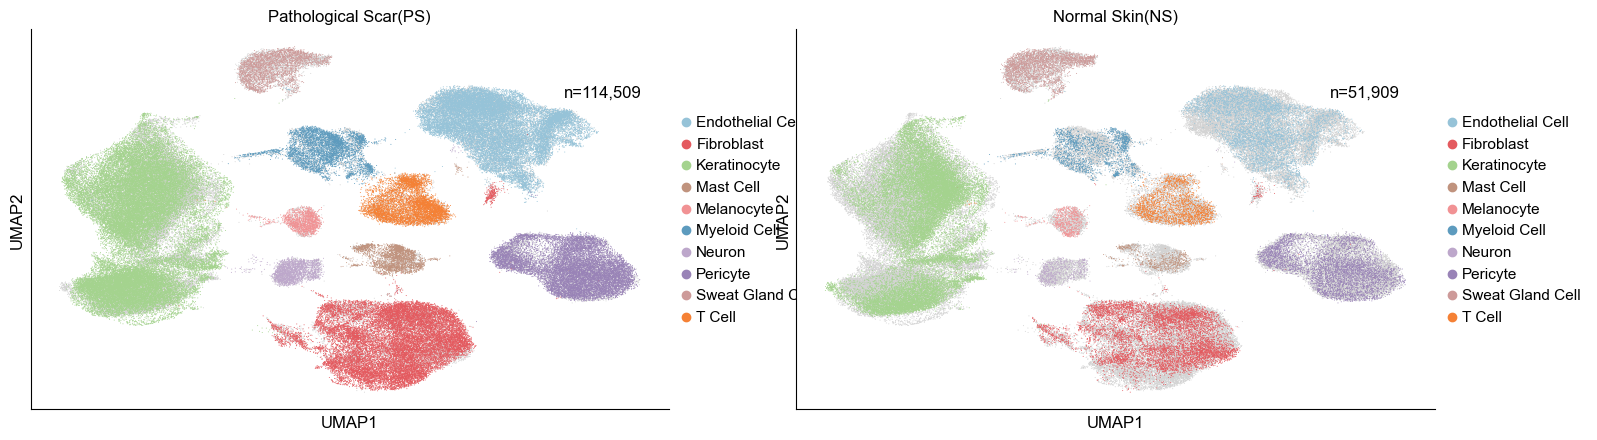

In [12]:
fig,axs = plt.subplots(1,2)
fig.set_figheight(5)
fig.set_figwidth(18)

sc.pl.embedding(adata[adata.obs['condition']!="Scar/keloid"],"umap",ax=axs[0],show=False,size=2.,title=None)
sc.pl.embedding(adata[adata.obs['condition']=="Scar/keloid"],"umap",color=["CellType"],ax=axs[0],show=False,size=2.,title=None)
axs[0].text(15,15,"n=114,509")
axs[0].set_title("Pathological Scar(PS)")

sc.pl.embedding(adata[adata.obs['condition']!="NS"],"umap",ax=axs[1],show=False,size=2.,title=None)
sc.pl.embedding(adata[adata.obs['condition']=="NS"],"umap",color=["CellType"],ax=axs[1],show=False,size=2.,title=None)
axs[1].text(15,15,"n=51,909")
axs[1].set_title("Normal Skin(NS)")

fig.savefig("Figure1C_1.pdf",format="pdf",bbox_inches="tight")
fig.show()

In [17]:
tmp = myutils.tl.calculate_cell_fraction(adata,group_by="CellType",sample_key="condition")
tmp

,Endothelial Cell,Fibroblast,Keratinocyte,Mast Cell,Melanocyte,Myeloid Cell,Neuron,Pericyte,Sweat Gland Cell,T Cell,condition,n_cells
0,0.108305,0.154540,0.485889,0.010750,0.012445,0.034753,0.010769,0.090967,0.053247,0.038336,NS,51909
1,0.184737,0.178038,0.352208,0.023832,0.013073,0.041045,0.018566,0.112227,0.024758,0.051516,Scar/keloid,114509


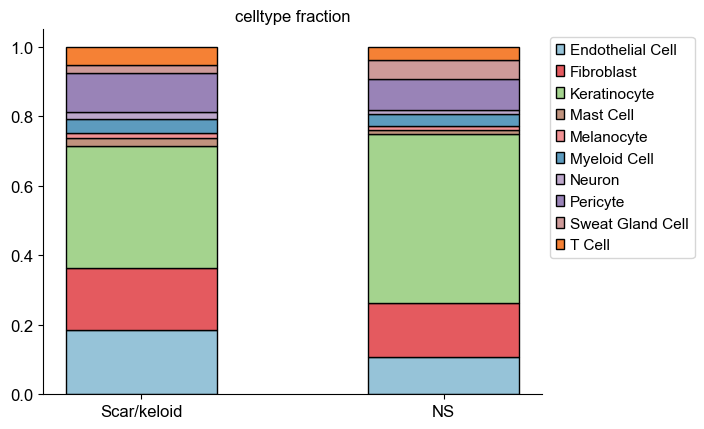

In [18]:
condition = ("Scar/keloid","NS")
tmp.index = tmp['condition']
tmp = tmp.loc[condition,:]

celltypes = ['Endothelial Cell', 'Fibroblast', 'Keratinocyte', 'Mast Cell',
       'Melanocyte', 'Myeloid Cell', 'Neuron', 'Pericyte', 'Sweat Gland Cell',
       'T Cell']

heights = {}
for celltype in celltypes:
    heights[celltype] = tmp[celltype].to_numpy()
    
colors = {}
for i, celltype in enumerate(celltypes):
    colors[celltype] = adata.uns['CellType_colors'][i]

width = 0.5

fig, ax = plt.subplots()
bottom = np.zeros(2)

for celltype, height in heights.items():
    p = ax.bar(condition, height, width, label=celltype, bottom=bottom,facecolor=colors[celltype],linewidth=1.,edgecolor="black")
    bottom += height
ax.grid(False)
ax.set_title("celltype fraction")
ax.legend(bbox_to_anchor=(1.0, 1.0))
fig.savefig("Figure1C_2.pdf",format="pdf",bbox_inches="tight")
plt.show()

In [13]:
adata.obs['celltype_leiden']= pd.Categorical(["_".join(i) for i in list(zip(adata.obs['CellType'],adata.obs['leiden']))])
adata.obs['celltype_leiden'].unique()

['Pericyte_3', 'T Cell_6', 'Fibroblast_2', 'Endothelial Cell_1', 'Mast Cell_11', ..., 'Keratinocyte_0', 'Keratinocyte_4', 'Myeloid Cell_9', 'Sweat Gland Cell_8', 'Melanocyte_12']
Length: 11
Categories (11, object): ['Endothelial Cell_1', 'Fibroblast_2', 'Keratinocyte_0', 'Keratinocyte_4', ..., 'Neuron_10', 'Pericyte_3', 'Sweat Gland Cell_8', 'T Cell_6']

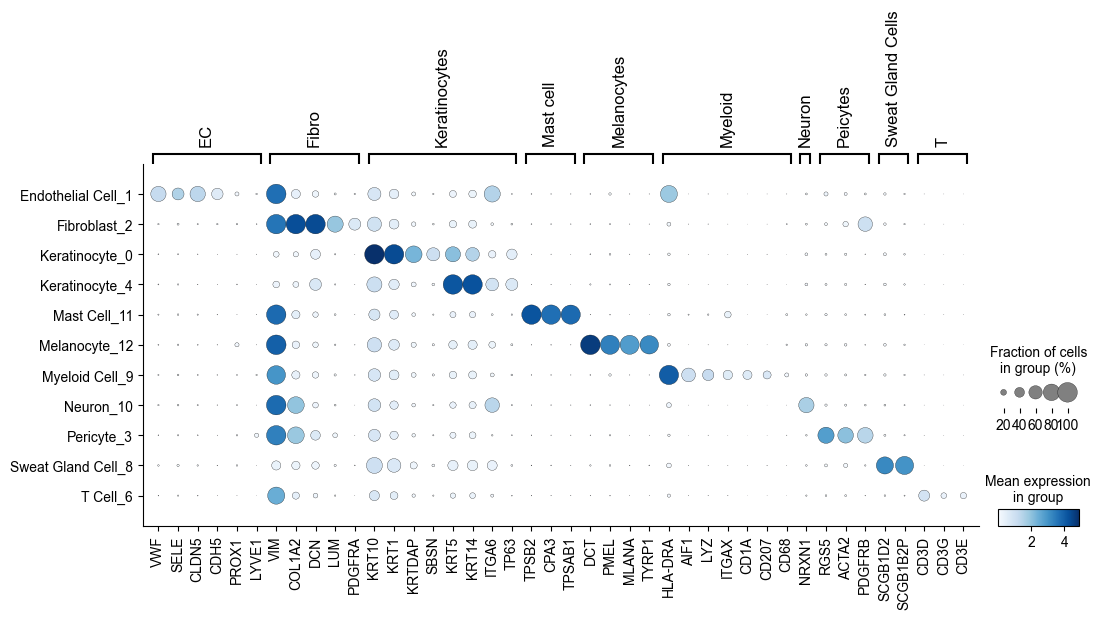

In [14]:
fig, ax = plt.subplots()
markers = {"EC":["VWF","SELE","CLDN5","CDH5","PROX1","LYVE1"],
           "Fibro":["VIM","COL1A2","DCN","LUM","PDGFRA"],
           "Keratinocytes":["KRT10","KRT1","KRTDAP","SBSN","KRT5","KRT14","ITGA6","TP63"],
           "Mast cell":["TPSB2","CPA3", "TPSAB1"],
           "Melanocytes":["DCT","PMEL","MLANA","TYRP1"],
           "Myeloid":["HLA-DRA","AIF1","LYZ","ITGAX","CD1A","CD207","CD68"],
           "Neuron":["NRXN1"],
           "Peicytes":["RGS5","ACTA2","PDGFRB"],
           "Sweat Gland Cells":["SCGB1D2","SCGB1B2P"],
           "T":["CD3D","CD3G","CD3E"]
           }
#order = ["Endothelial Cell_1","Fibroblast_2","Keratinocyte_0","Keratinocyte_4"]
sc.pl.dotplot(adata, markers,groupby="celltype_leiden",show=False,ax=ax,
             categories_order=None,cmap="Blues")
fig.set_figheight(6)
fig.set_figwidth(12)
fig.savefig("./FigureS1.pdf",format="pdf",dpi=300,bbox_inches ="tight")

plt.show()

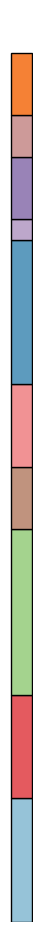

In [15]:
fig,ax = plt.subplots()
fig.set_figheight(12)
fig.set_figwidth(0.3)
#colors_list = np.array(['#1f77b4','#ff7f0e','#279e68','#aa40fc','#8c564b','#e377c2','#b5bd61','#17becf','#d62728'])
colors_list = adata.uns['CellType_colors']
condition = ("CellType")
celltypes = markers.keys()

heights = {}
for celltype in celltypes:
    heights[celltype] = len(markers[celltype])
    
colors = {}
for i, celltype in enumerate(celltypes):
    colors[celltype] = colors_list[i]

width = 0.2
bottom = np.zeros(1)

for celltype, height in heights.items():
    p = ax.bar(condition, height, width, label=celltype, bottom=bottom,facecolor=colors[celltype],linewidth=1.,edgecolor="black")
    bottom += height
#ax.legend(bbox_to_anchor=(1.0, 1.0))
ax.grid(False)
ax.axis(False)
fig.savefig("./FigureS1_2.pdf",format="pdf",bbox_inches="tight")
plt.show()

Storing dendrogram info using `.uns['dendrogram_CellType']`


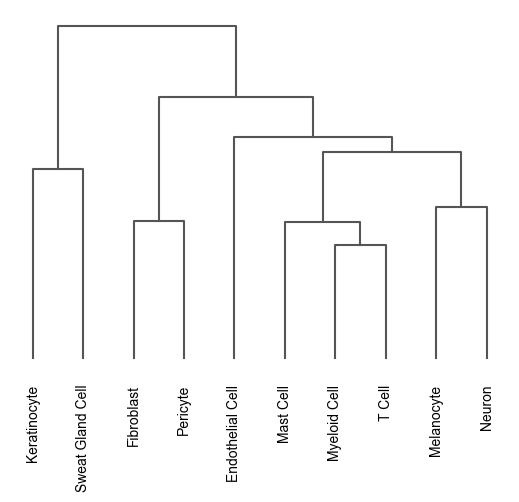

In [16]:
fig,ax = plt.subplots()
sc.tl.dendrogram(adata,use_rep="X_pca",groupby="CellType")
sc.pl.dendrogram(adata,groupby="CellType",show=False,ax=ax)
fig.savefig("./FigureS1B.pdf",format="pdf",bbox_inches="tight")
plt.show()

In [21]:
tmp = myutils.tl.calculate_cell_fraction(adata,group_by="CellType",sample_key="sample")
tmp

,Endothelial Cell,Fibroblast,Keratinocyte,Mast Cell,Melanocyte,Myeloid Cell,Neuron,Pericyte,Sweat Gland Cell,T Cell,sample,n_cells
0,0.266013,0.205802,0.077565,0.037822,0.001060,0.040074,0.023647,0.239187,0.002782,0.106048,HS1,15097
1,0.241932,0.262462,0.122327,0.017809,0.002411,0.036706,0.025663,0.218757,0.008010,0.063924,HS2,12859
2,0.153102,0.286786,0.235682,0.041921,0.012057,0.067928,0.029863,0.070592,0.026498,0.075570,HS3,14265
3,0.265626,0.164560,0.258917,0.036443,0.013419,0.032276,0.020129,0.110742,0.057490,0.040398,HS4,14159
4,0.123603,0.201852,0.465347,0.005642,0.006494,0.028745,0.012137,0.101565,0.035878,0.018737,Normal1,9393
5,0.096135,0.169168,0.493679,0.009550,0.007822,0.030105,0.002910,0.084129,0.068213,0.038290,Normal2,10995
6,0.094848,0.161655,0.507572,0.004275,0.026085,0.034997,0.014274,0.066807,0.065937,0.023549,Normal3,13801
7,0.118228,0.114842,0.475056,0.019244,0.007844,0.040632,0.012190,0.108409,0.043284,0.060271,Normal4,17720
8,0.028675,0.065899,0.806851,0.006305,0.019764,0.039648,0.006972,0.020491,0.001576,0.003819,keloid1,16495
9,0.013681,0.020216,0.887591,0.000523,0.017863,0.044005,0.001656,0.008452,0.001394,0.004618,keloid2,11476


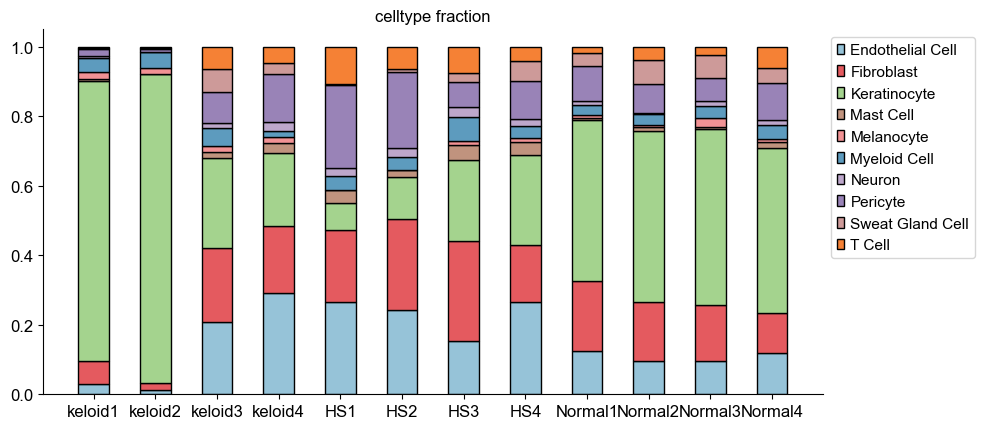

In [23]:
condition = ("keloid1","keloid2","keloid3","keloid4","HS1","HS2","HS3","HS4","Normal1","Normal2","Normal3","Normal4")
tmp.index = tmp['sample']
tmp = tmp.loc[condition,:]

celltypes = ['Endothelial Cell', 'Fibroblast', 'Keratinocyte', 'Mast Cell',
       'Melanocyte', 'Myeloid Cell', 'Neuron', 'Pericyte', 'Sweat Gland Cell',
       'T Cell']

heights = {}
for celltype in celltypes:
    heights[celltype] = tmp[celltype].to_numpy()
    
colors = {}
for i, celltype in enumerate(celltypes):
    colors[celltype] = adata.uns['CellType_colors'][i]

width = 0.5

fig, ax = plt.subplots()
bottom = np.zeros(len(condition))

for celltype, height in heights.items():
    p = ax.bar(condition, height, width, label=celltype, bottom=bottom,facecolor=colors[celltype],linewidth=1.,edgecolor="black")
    bottom += height
ax.grid(False)
fig.set_figwidth(10)
ax.set_title("celltype fraction")
ax.legend(bbox_to_anchor=(1.0, 1.0))
fig.savefig("FigureS1C.pdf",format="pdf",bbox_inches="tight")
plt.show()

In [19]:
markers = {"Myeloid":["LYZ","AIF1","CD68","ITGAX","CD207","CD1A"],
          "Fibro":["COL1A2","LUM","DCN","PDGFRA"]}

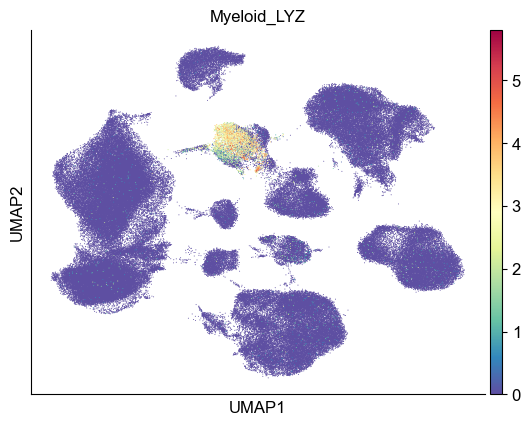

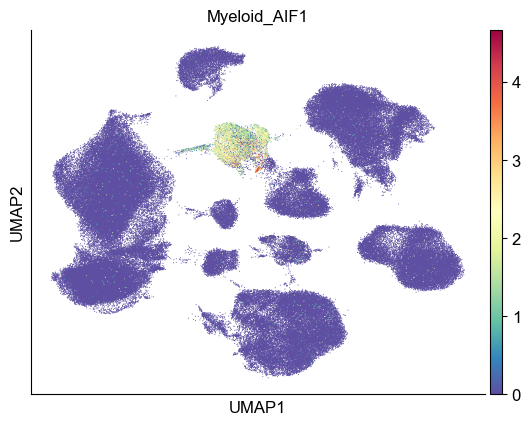

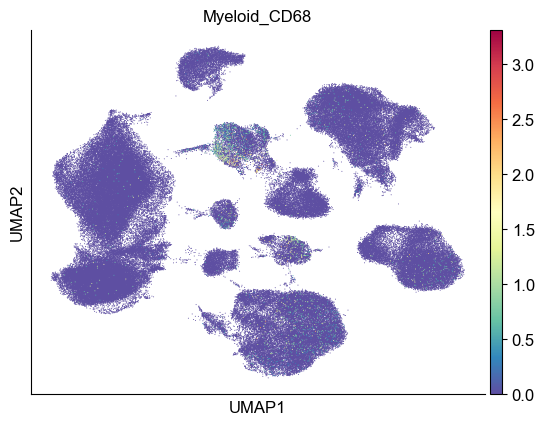

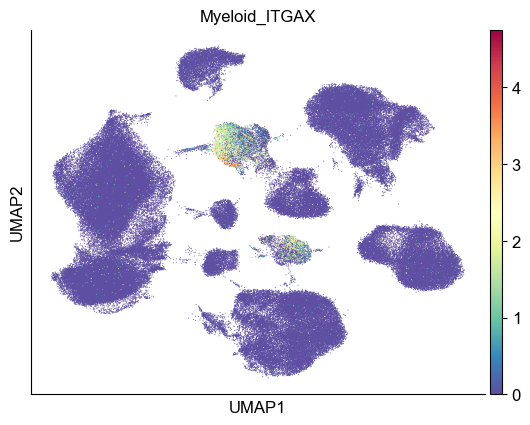

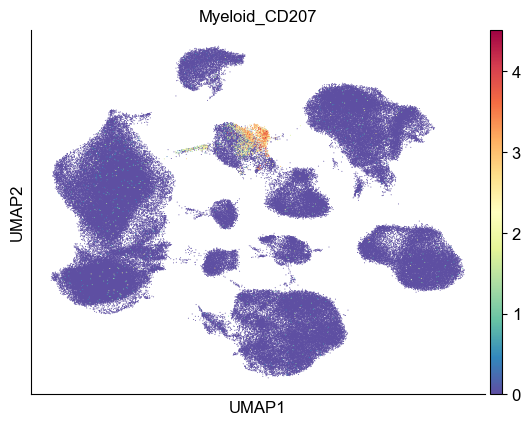

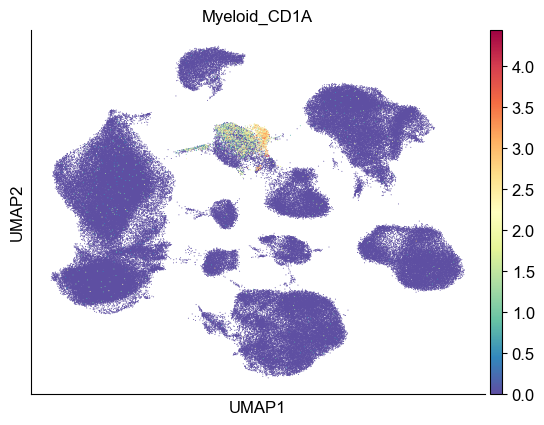

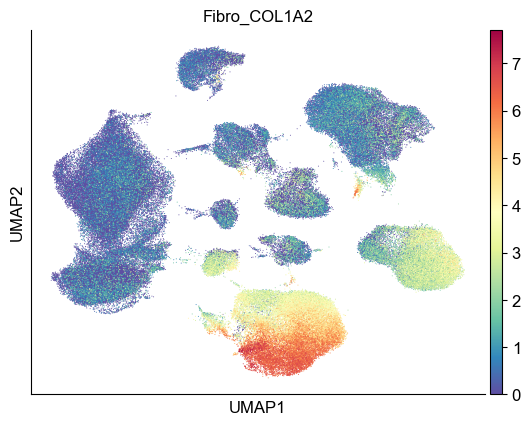

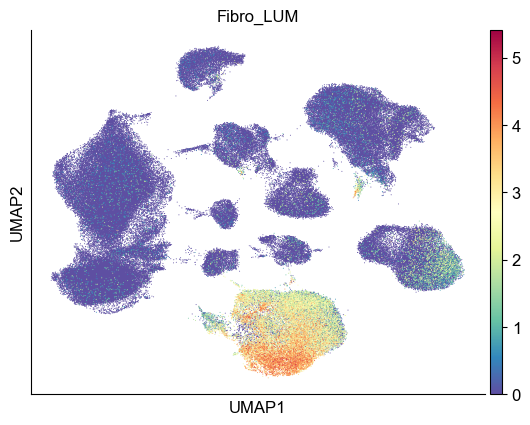

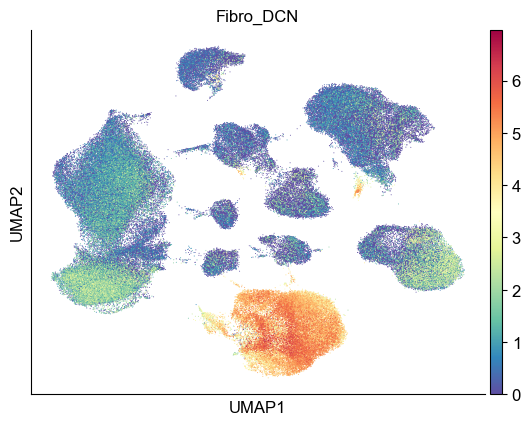

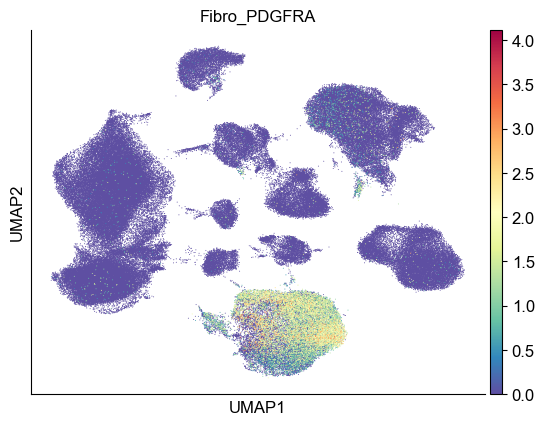

In [20]:
for group in markers.keys():
    genes = markers[group]
    for gene in genes:
        fig,ax = plt.subplots()
        sc.pl.embedding(adata,"umap",color=gene,ax=ax,show=False,size=2.,title=group+"_"+gene)
        fig.savefig("./figureS1D_S1H/"+group+"_"+gene+".pdf",format="pdf",bbox_inches="tight")
        plt.show()